In [1]:
#First I want to load and clean the opening cells
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("all_data.csv")

# rename column (makes life easier)
df = df.rename(columns={
    "Life expectancy at birth (years)": "LE"
})

df.head()

,Country,Year,LE,GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10


In [2]:
#Printing cell info in order to explore and better understand data
print(df.info())
print(df.describe())
print(df['Country'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  96 non-null     object 
 1   Year     96 non-null     int64  
 2   LE       96 non-null     float64
 3   GDP      96 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.1+ KB
None
              Year         LE           GDP
count    96.000000  96.000000  9.600000e+01
mean   2007.500000  72.789583  3.880499e+12
std       4.633971  10.672882  5.197561e+12
min    2000.000000  44.300000  4.415703e+09
25%    2003.750000  74.475000  1.733018e+11
50%    2007.500000  76.750000  1.280220e+12
75%    2011.250000  78.900000  4.067510e+12
max    2015.000000  81.000000  1.810000e+13
['Chile' 'China' 'Germany' 'Mexico' 'United States of America' 'Zimbabwe']


In [4]:
print(df['Year'].unique())

[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015]


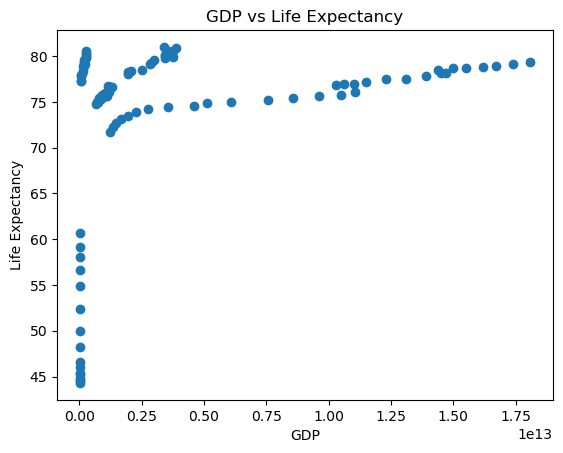

In [5]:
#First core plot analysis
#Does higher GDP = higher life expectancy
plt.scatter(df['GDP'], df['LE'])
plt.xlabel("GDP")
plt.ylabel("Life Expectancy")
plt.title("GDP vs Life Expectancy")
plt.show()

In [6]:
#Showing correlation of the 2 plots
corr = np.corrcoef(df['GDP'], df['LE'])[0][1]
print("Correlation:", corr)

Correlation: 0.3432067484491559


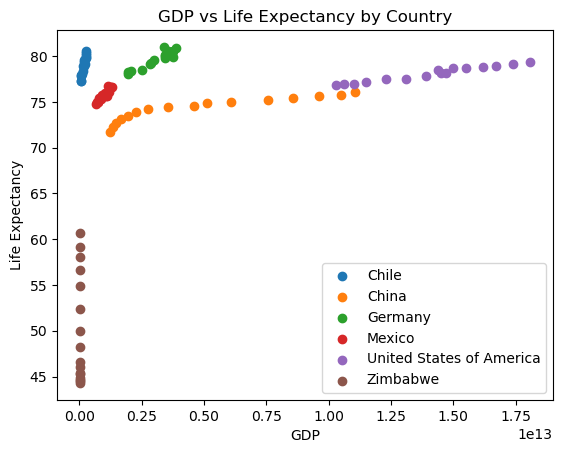

In [7]:
#Now breaking the GDP vs life expectancy down by country
countries = df['Country'].unique()

for country in countries:
    subset = df[df['Country'] == country]
    plt.scatter(subset['GDP'], subset['LE'], label=country)

plt.legend()
plt.xlabel("GDP")
plt.ylabel("Life Expectancy")
plt.title("GDP vs Life Expectancy by Country")
plt.show()

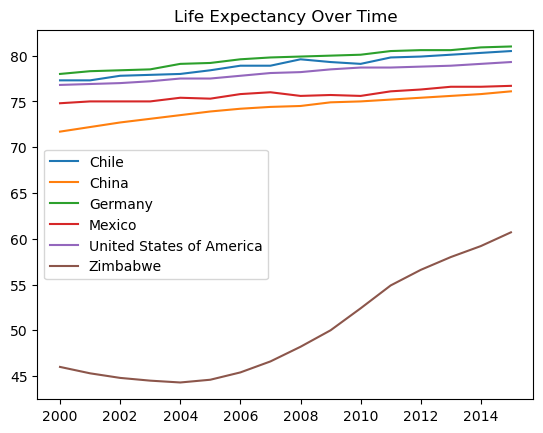

In [8]:
#Plotting how the life expectancy per country changes over time
for country in countries:
    subset = df[df['Country'] == country]
    plt.plot(subset['Year'], subset['LE'], label=country)

plt.legend()
plt.title("Life Expectancy Over Time")
plt.show()

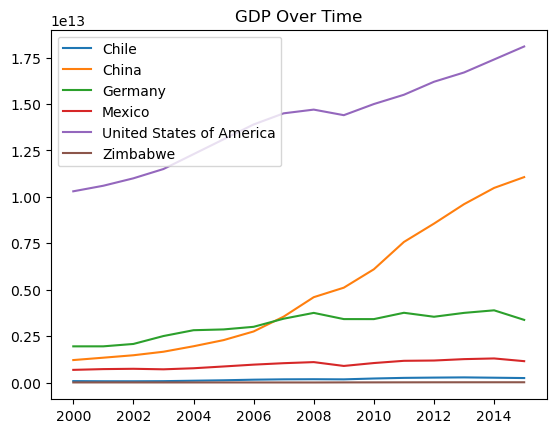

In [10]:
#Plotting how the GDP for each country grows over time
for country in countries:
    subset = df[df['Country'] == country]
    plt.plot(subset['Year'], subset['GDP'], label=country)

plt.legend()
plt.title("GDP Over Time")
plt.show()

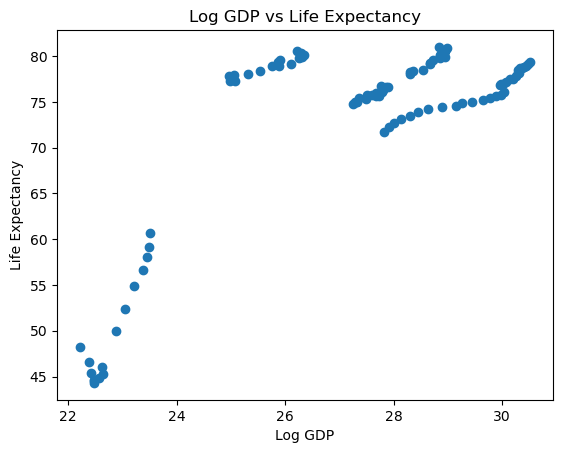

In [9]:
#Finally, logging the GDP to reveal the clearest relationship\ 
#between GDP and life expectancy\
df['log_GDP'] = np.log(df['GDP'])

plt.scatter(df['log_GDP'], df['LE'])
plt.xlabel("Log GDP")
plt.ylabel("Life Expectancy")
plt.title("Log GDP vs Life Expectancy")
plt.show()

In [11]:
#In conclusion:

In [12]:
#This analysis explored the relationship between GDP and life expectancy across six countries\ 
#from 2000 to 2015. Overall, there is a clear positive correlation between GDP and life\ 
#expectancy, indicating that countries with higher economic output tend to have longer average lifespans.

#However, this relationship varies significantly by country. When examining each country individually,\ 
#the correlation between GDP growth and life expectancy is generally strong and positive. As GDP increases\ 
#over time within a country, life expectancy tends to rise as well. This suggests that economic growth can\ 
#contribute to improvements in healthcare, infrastructure, and overall quality of life.

#Across countries, however, the relationship is less consistent. Some countries with very high GDP, such\
#as the United States, do not have proportionally higher life expectancy compared to countries with lower\ 
#GDP. This indicates that factors beyond economic output—such as healthcare systems, lifestyle, and\ 
#inequality—play a significant role in determining life expectancy.

#One surprising pattern is that life expectancy increases tend to slow or plateau at higher GDP levels.\
#In contrast, countries with lower GDP often show more noticeable gains in life expectancy as their economies\
#grow. This suggests diminishing returns, where initial economic growth has a larger impact on public health\
#than later growth.

#In conclusion, while GDP and life expectancy are positively correlated, the strength and nature of this\
#relationship depend heavily on the country and its unique social and economic context.